In [1]:
pip install yfinance scikit-learn matplotlib pandas numpy

   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.7 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.7 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.7 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.7 MB ? eta -:--:--
   ------------ --------------------------- 0.5/1.7 MB 295.9 kB/s eta 0:00:04
   ------------ --------------------------- 0.5/1.7 MB 295.9 kB/s eta 0:00:04
   ------------ --------------------------- 0.5/1.7 MB 295.9 kB/s eta 0:00:04
   ------------ --------------------------- 0.5/1.7 MB 295.9 kB/s eta 0:00:04
   ------------------ --------------------- 0.8/1.7 MB 305.3 kB/s e


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
# Download historical stock data for Apple and Tesla
apple = yf.download('AAPL', start='2020-01-01', end='2024-01-01')
tesla = yf.download('TSLA', start='2020-01-01', end='2024-01-01')

# Preview the data
print(apple.head())

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2020-01-02  72.333862  72.394070  71.091169  71.344039  135480400
2020-01-03  71.630638  72.389257  71.406666  71.563205  146322800
2020-01-06  72.201431  72.239965  70.503569  70.754036  118387200
2020-01-07  71.861855  72.466338  71.642697  72.211056  108872000
2020-01-08  73.017838  73.318877  71.565621  71.565621  132079200


In [4]:
# Function to prepare data for any stock
def prepare_data(df):
    
    # Use Open, High, Low, Volume as input features (X)
    X = df[['Open', 'High', 'Low', 'Volume']]
    
    # Use Close price as the target we want to predict (y)
    y = df['Close']
    
    # Split data into 80% training and 20% testing
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    return X_train, X_test, y_train, y_test

# Prepare data for both Apple and Tesla
apple_X_train, apple_X_test, apple_y_train, apple_y_test = prepare_data(apple)
tesla_X_train, tesla_X_test, tesla_y_train, tesla_y_test = prepare_data(tesla)

print("Data prepared successfully!")

Data prepared successfully!


In [5]:
# Function to train both models on a given stock's data
def train_models(X_train, y_train):
    
    # Initialize Linear Regression model
    lr_model = LinearRegression()
    
    # Initialize Random Forest model with 100 decision trees
    rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
    
    # Train Linear Regression on the training data
    lr_model.fit(X_train, y_train)
    
    # Train Random Forest on the training data
    rf_model.fit(X_train, y_train)
    
    return lr_model, rf_model

# Train models for Apple
apple_lr, apple_rf = train_models(apple_X_train, apple_y_train)

# Train models for Tesla
tesla_lr, tesla_rf = train_models(tesla_X_train, tesla_y_train)

print("Models trained successfully!")

C:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
C:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Models trained successfully!


In [6]:
# Function to make predictions using both trained models
def make_predictions(lr_model, rf_model, X_test):
    
    # Use Linear Regression model to predict closing prices
    lr_predictions = lr_model.predict(X_test)
    
    # Use Random Forest model to predict closing prices
    rf_predictions = rf_model.predict(X_test)
    
    return lr_predictions, rf_predictions

# Make predictions for Apple
apple_lr_pred, apple_rf_pred = make_predictions(apple_lr, apple_rf, apple_X_test)

# Make predictions for Tesla
tesla_lr_pred, tesla_rf_pred = make_predictions(tesla_lr, tesla_rf, tesla_X_test)

print("Predictions made successfully!")

Predictions made successfully!


In [7]:
# Function to print accuracy scores for both models
def evaluate_models(y_test, lr_pred, rf_pred, stock_name):
    
    # Calculate Root Mean Squared Error for Linear Regression (lower is better)
    lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
    
    # Calculate Root Mean Squared Error for Random Forest (lower is better)
    rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
    
    # Calculate R2 Score for Linear Regression (closer to 1 is better)
    lr_r2 = r2_score(y_test, lr_pred)
    
    # Calculate R2 Score for Random Forest (closer to 1 is better)
    rf_r2 = r2_score(y_test, rf_pred)
    
    # Print results for the stock
    print(f"--- {stock_name} ---")
    print(f"Linear Regression  -> RMSE: {lr_rmse:.2f} | R2 Score: {lr_r2:.2f}")
    print(f"Random Forest      -> RMSE: {rf_rmse:.2f} | R2 Score: {rf_r2:.2f}")
    print()

# Evaluate models for Apple
evaluate_models(apple_y_test, apple_lr_pred, apple_rf_pred, "Apple (AAPL)")

# Evaluate models for Tesla
evaluate_models(tesla_y_test, tesla_lr_pred, tesla_rf_pred, "Tesla (TSLA)")

--- Apple (AAPL) ---
Linear Regression  -> RMSE: 0.95 | R2 Score: 1.00
Random Forest      -> RMSE: 1.35 | R2 Score: 1.00

--- Tesla (TSLA) ---
Linear Regression  -> RMSE: 3.33 | R2 Score: 1.00
Random Forest      -> RMSE: 4.57 | R2 Score: 1.00



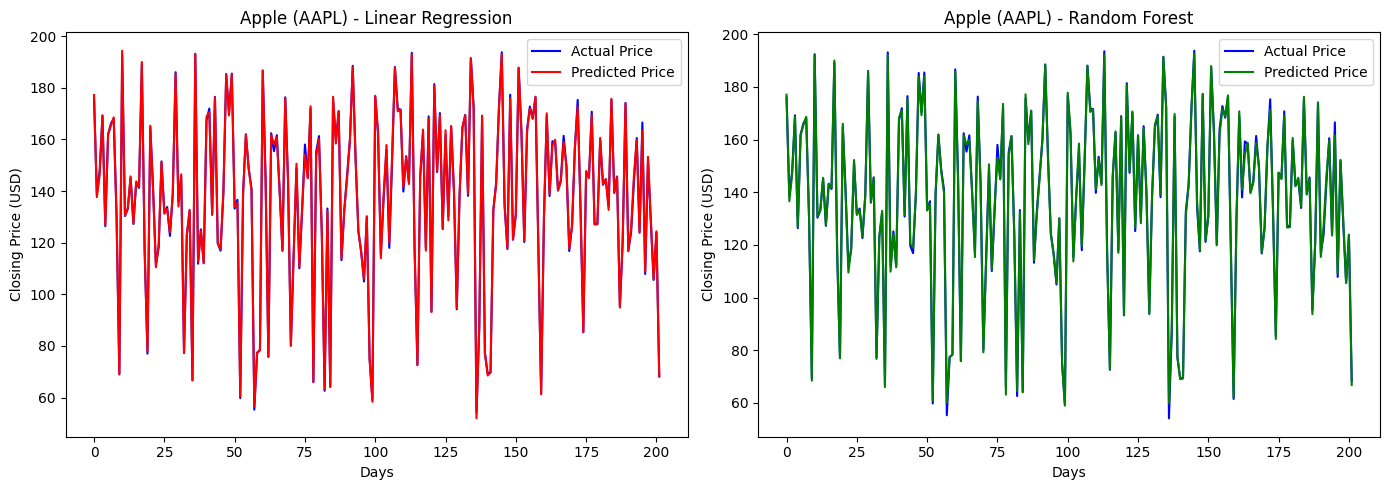

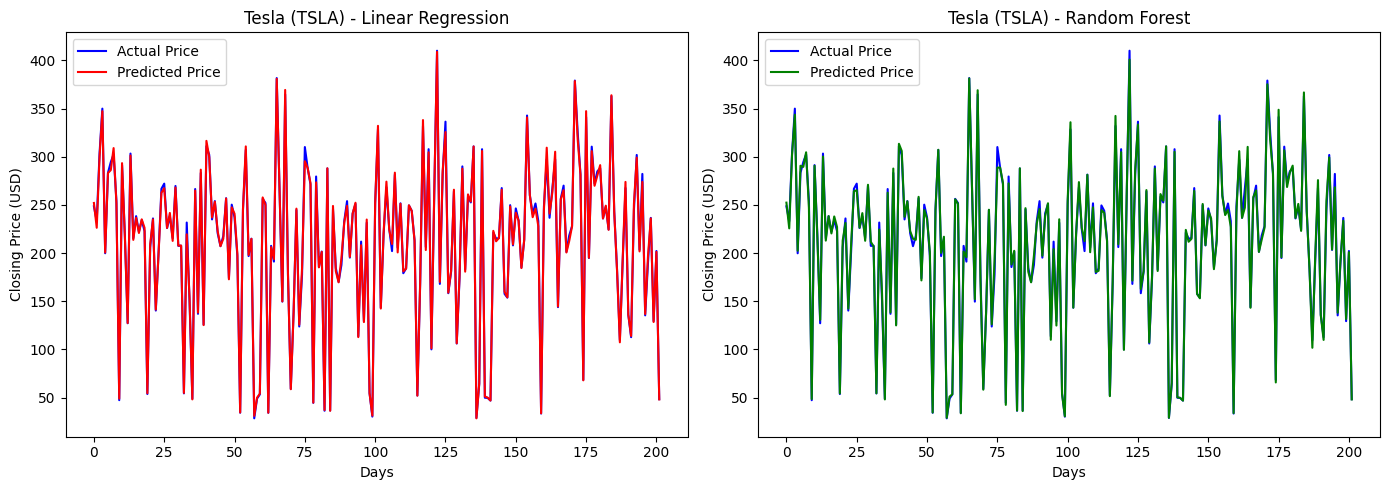

In [8]:
# Function to plot actual vs predicted closing prices for both models
def plot_predictions(y_test, lr_pred, rf_pred, stock_name):
    
    # Create a figure with a specific size
    plt.figure(figsize=(14, 5))
    
    # --- Plot 1: Linear Regression ---
    plt.subplot(1, 2, 1)
    
    # Plot actual closing prices in blue
    plt.plot(y_test.values, color='blue', label='Actual Price')
    
    # Plot Linear Regression predicted prices in red
    plt.plot(lr_pred, color='red', label='Predicted Price')
    
    # Add title and labels
    plt.title(f'{stock_name} - Linear Regression')
    plt.xlabel('Days')
    plt.ylabel('Closing Price (USD)')
    plt.legend()
    
    # --- Plot 2: Random Forest ---
    plt.subplot(1, 2, 2)
    
    # Plot actual closing prices in blue
    plt.plot(y_test.values, color='blue', label='Actual Price')
    
    # Plot Random Forest predicted prices in green
    plt.plot(rf_pred, color='green', label='Predicted Price')
    
    # Add title and labels
    plt.title(f'{stock_name} - Random Forest')
    plt.xlabel('Days')
    plt.ylabel('Closing Price (USD)')
    plt.legend()
    
    # Display the plots
    plt.tight_layout()
    plt.show()

# Plot predictions for Apple
plot_predictions(apple_y_test, apple_lr_pred, apple_rf_pred, "Apple (AAPL)")

# Plot predictions for Tesla
plot_predictions(tesla_y_test, tesla_lr_pred, tesla_rf_pred, "Tesla (TSLA)")

In [12]:
# Function to predict the next day's closing price
def predict_next_day(lr_model, rf_model, df, stock_name):
    
    # Get the last row of data (most recent day)
    last_row = df[['Open', 'High', 'Low', 'Volume']].iloc[-1].values.reshape(1, -1)
    
    # Predict using Linear Regression and extract the single value using item()
    lr_next = lr_model.predict(last_row).item()
    
    # Predict using Random Forest and extract the single value using item()
    rf_next = rf_model.predict(last_row).item()
    
    # Print the predictions
    print(f"--- {stock_name} Next Day Prediction ---")
    print(f"Linear Regression  -> Predicted Close: ${lr_next:.2f}")
    print(f"Random Forest      -> Predicted Close: ${rf_next:.2f}")
    print()

# Predict next day closing price for Apple
predict_next_day(apple_lr, apple_rf, apple, "Apple (AAPL)")

# Predict next day closing price for Tesla
predict_next_day(tesla_lr, tesla_rf, tesla, "Tesla (TSLA)")

--- Apple (AAPL) Next Day Prediction ---
Linear Regression  -> Predicted Close: $190.32
Random Forest      -> Predicted Close: $190.40

--- Tesla (TSLA) Next Day Prediction ---
Linear Regression  -> Predicted Close: $248.79
Random Forest      -> Predicted Close: $250.19

